In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('washington_ultimate.csv')

## Can I predict the price of a house?

The goal of the project is to predict the lastSoldPrice variable taking into account the difference of prices in different regions

In [4]:
print(df.tail())
print(df.describe())
print(df.info())
print(df.shape)
print(print(df.isnull().sum()))

           zip           type  year_built  listPrice  lastSoldPrice  \
12012  99218.0  single_family      1978.0   524957.0       504906.0   
12013  98251.0  single_family      1999.0   599927.0       589926.0   
12014  98251.0  single_family      2019.0   514909.0       512575.0   
12015  98258.0  single_family      1993.0   599874.0       624935.0   
12016  98310.0  single_family      1955.0   439912.0       433077.0   

       list_to_sold_ratio    sqft  price_per_sqft  stories  beds  baths  \
12012              0.9618  3270.0          154.41      NaN   4.0    3.0   
12013              0.9833  1710.0          344.99      2.0   3.0    3.0   
12014              0.9955  1810.0          283.19      2.0   3.0    2.0   
12015              1.0418  1090.0          573.33      1.0   3.0    2.0   
12016              0.9845  1300.0          333.14      1.0   3.0    2.0   

       baths_full  baths_full_calc  garage  \
12012         3.0              3.0     2.0   
12013         2.0             

## Phase 1: Data Loading and Initial Look

* **Total Rows:** 12,017
* **Total Features:** 15

| Feature | Data Type | Range / Values | Missing Values | Outliers Found |
| :--- | :--- | :--- | :--- | :--- |
| **zip** | Categorical | 98001 to 99403 | 3 | None (Location) |
| **type** | Categorical | Single Family, Multi-Family, etc. | 0 | None |
| **year_built** | Numerical | 1875 to 2026 | 860 | None |
| **listPrice** | Numerical | \$1k to \$10.9M | 1,692 | Yes (\$10M+) |
| **lastSoldPrice** | **Target (Num)** | \$1k to \$15.7M | 15 | Yes (\$15M+) |
| **sqft** | Numerical | 120 to 29,680 | 872 | Yes (29k sqft) |
| **stories** | Numerical | 0 to 31 | 1,511 | Yes (31 stories) |
| **beds** | Numerical | 0 to 18 | 932 | Yes (18 beds) |
| **baths** | Numerical | 0 to 20 | 484 | Yes (20 baths) |
| **garage** | Numerical | 1 to 10 | 9,654 | None |

---

### Key Observations & Definitions

* **Target Assessment:** The target variable is `lastSoldPrice`. The extreme range (\$1k - \$15.7M) suggests significant variance in the market.
* **Missing Data Strategy:** The `garage` feature is missing over 80% of its data (9,654 nulls). These will be filled with `0` assuming no garage is present.
* **Outlier Definition:** Outliers are defined as data points that deviate significantly from the norm, such as houses with 31 stories, 18 bedrooms, or sales prices under \$5,000, which may represent non-market transactions.
* **Data Preparation Needs:** Categorical features like `zip` and `type` must be converted to strings and one-hot encoded for the model to process them.

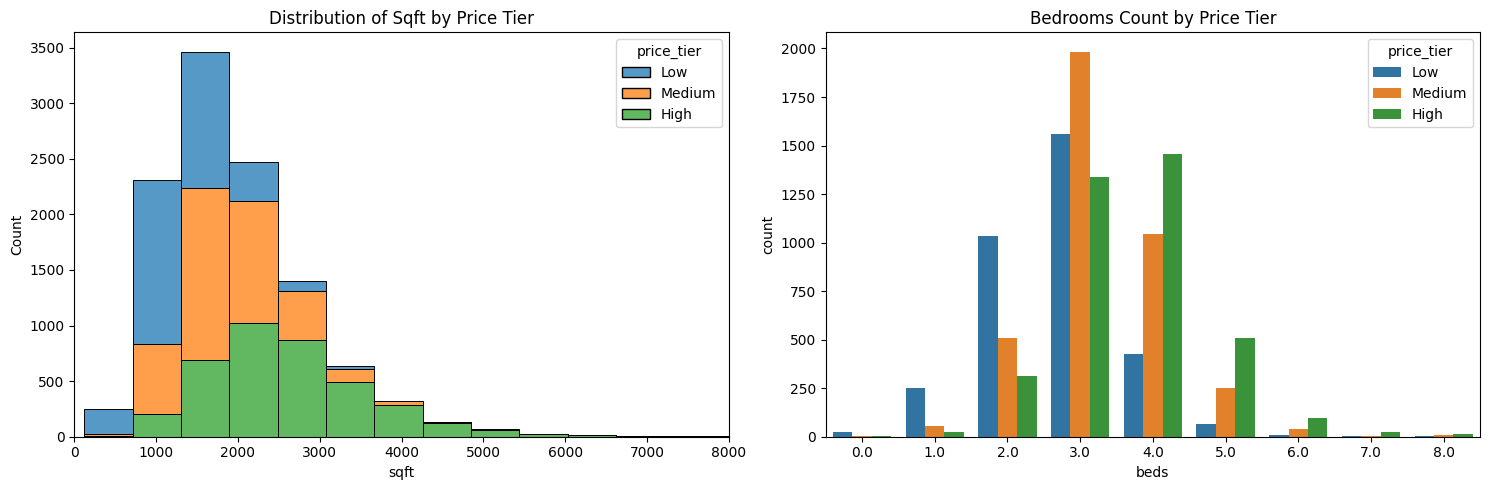

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create Price Tiers for visualization (3 classes based on price)
# This satisfies the requirement to compare histograms between "classes"
df['price_tier'] = pd.qcut(df['lastSoldPrice'], 3, labels=["Low", "Medium", "High"])

# 2. Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Square Footage vs Price Tier
sns.histplot(data=df, x='sqft', hue='price_tier', multiple="stack", ax=axes[0], bins=50)
axes[0].set_title('Distribution of Sqft by Price Tier')
axes[0].set_xlim(0, 8000) # Cutting off extremes for better visibility

# Plot 2: Bedrooms vs Price Tier
sns.countplot(data=df, x='beds', hue='price_tier', ax=axes[1])
axes[1].set_title('Bedrooms Count by Price Tier')
axes[1].set_xlim(-0.5, 8.5)

plt.tight_layout()
plt.show()

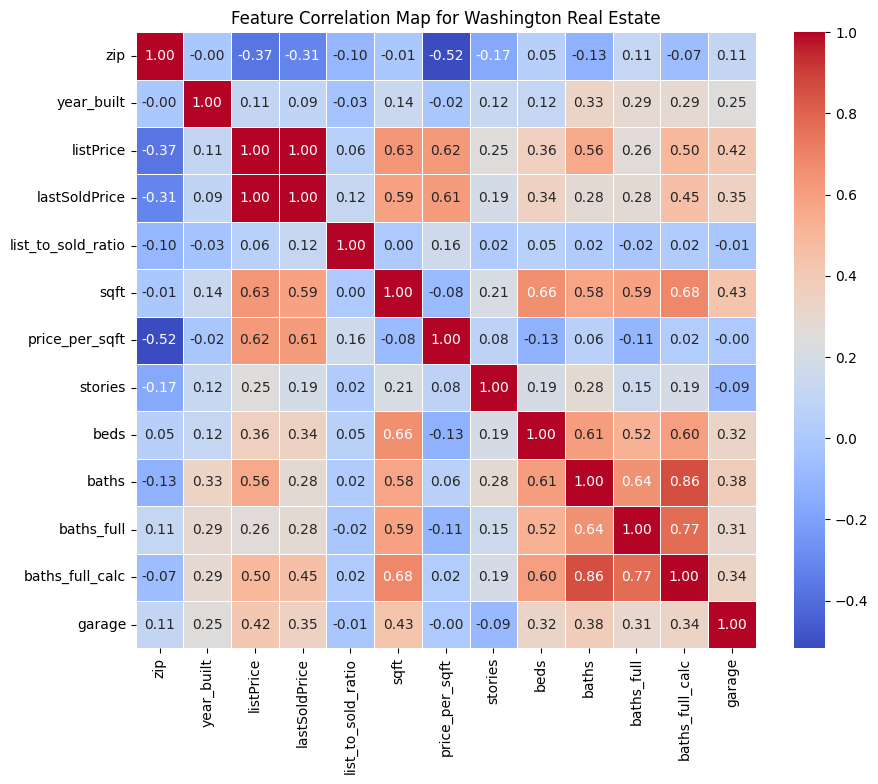

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Map for Washington Real Estate')
plt.show()

In [102]:
#Some notes i got. listPrice can be a leak for my data since its highly correlated to the soldPrice. TAKE IT OUT
#list_to_sold_ratio is another leak since it calculates the ratio using the soldPrice. DROP IT
#price_per_sqrt is another leak. DROP IT
#baths full has the same correlation to price so I can drop it.

In [23]:
cols_to_keep = [
    'zip', 'year_built', 'sqft', 'stories', 
    'beds', 'baths', 'garage', 'lastSoldPrice','type'
]
df_clone = df[cols_to_keep].copy()
df_clone = df_clone.dropna(subset=['lastSoldPrice'])  #I dropped the NA values of lastSoldPrice because it was only 15 rows which is not a lot compared to 12k rows
print(f"Original shape: {df.shape}")
print(f"Clone shape: {df_clone.shape}")
print(df_clone.head())

#Specifically fill 'garage' with 0
df_clone['garage'] = df_clone['garage'].fillna(0)

#Fill any remaining NaNs with the Median
#This ensures columns like beds/baths/sqft get typical values, not 0s.
df_clone = df_clone.fillna(df_clone.median(numeric_only=True))

#ONE-HOT ENCODE the 'type' column
#This turns 'type' into columns like 'type_condo', 'type_house', etc.
df_clone = pd.get_dummies(df_clone, columns=['type'], prefix='type')

#Verify there are no more missing values
print(df_clone.isnull().sum())
print(df_clone.head())
print(df_clone.shape)
print(df.shape)

#Create the region
df_clone['region'] = df_clone['zip'].astype(str).str[:3]

#Convert ZIP to a string so the model treats it as a category, not a number (Step 2)
df_clone['zip_cat'] = df_clone['zip'].astype(str)

#One-Hot Encode BOTH
# This captures the broad region AND the specific neighborhood
df_clone = pd.get_dummies(df_clone, columns=['region', 'zip_cat'], prefix=['reg', 'zip'])

#drop the original numerical zip
df_clone = df_clone.drop(columns=['zip'])

print(f"New Shape: {df_clone.shape}") 

Original shape: (12017, 16)
Clone shape: (12002, 9)
       zip  year_built    sqft  stories  beds  baths  garage  lastSoldPrice  \
0  99156.0      1997.0  2710.0      1.0   3.0    3.0     3.0       875085.0   
1  99006.0      1900.0  1460.0      2.0   3.0    2.0     NaN       347902.0   
2  98843.0      2017.0  3770.0      2.0   4.0    4.0     NaN      2539927.0   
3  98311.0      1990.0  4250.0      2.0   3.0    4.0     NaN       744599.0   
4  98102.0      1926.0  3500.0      2.0   3.0    3.0     NaN      1790076.0   

            type  
0  single_family  
1  single_family  
2  single_family  
3  single_family  
4  single_family  
zip                   0
year_built            0
sqft                  0
stories               0
beds                  0
baths                 0
garage                0
lastSoldPrice         0
type_condo            0
type_coop             0
type_farm             0
type_land             0
type_mobile           0
type_multi_family     0
type_other            0

In [27]:
# Calculate the 'middle' range
Q1 = df_clone['lastSoldPrice'].quantile(0.25)
Q3 = df_clone['lastSoldPrice'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds (1.5 is the standard multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data
df_final = df_clone[(df_clone['lastSoldPrice'] >= lower_bound) & (df_clone['lastSoldPrice'] <= upper_bound)]

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Define Features (X) and Target (y)
# We use the log of the price because it's less skewed by outliers
X = df_final.drop(columns=['lastSoldPrice'])
y = np.log1p(df_final['lastSoldPrice']) 

# 2. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Ridge Regression Model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred_log = model.predict(X_test)

# Convert back from log scale to actual dollars for the metrics
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test, y_pred_log) # R2 is typically calculated on the log-scale for this type of data

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: $111,533.82
R2 Score: 0.6401
